# P&P Feature Ablation at k=1

Does **P&P uncertainty** add predictive signal beyond the **action vector** for early failure detection?

We train the same classifiers on three feature sets at cutoff **k=1** (chunks 0 and 1):

| Feature set | Description | Dim |
|---|---|---|
| `action_only` | per-dim mean action `a_mean_vec` | 14 |
| `uncertainty_only` | per-dim P&P uncertainty `u_vec` | 14 |
| `both` | concatenated u + a (original notebook) | 28 |

**Models:** Logistic Regression, Random Forest, GBM, MLP  
**Evaluation:** stratified 5-fold CV, OOF predictions, F1-optimal threshold, bootstrap AUC CIs

---

### Data provenance (must match `failure_classifier.ipynb` exactly)

| | |
|---|---|
| **Benchmark** | **LIBERO-PRO** (custom perturbed suites), not standard LIBERO |
| **Policy** | **π0.5** — `lerobot/pi05_libero_finetuned` (not SmolVLA) |
| **Episodes** | 6 suites × 10 tasks × 10 init states = **600** |
| **P&P phase used** | `pnp_mode='uncertainty'` only (`PHASE='uncertainty'`) |
| **P&P config at collection** | `step_indices=(3,4)`, `num_iterations=3`, `num_inference_steps=10` |
| **Database** | `rollouts_jeff_dimensional.db` |
| **Default path** | `MyDrive/cs159_jeff/libero_pro_results/` (Jeff's Colab Drive) |
| **Rollout source notebook** | `pnp_pro_analysis_dimensions.ipynb` (collects data; DB has ~1800 rows across 3 phases, classifier uses the 600 uncertainty rows) |

**Suites:** `libero_object_temp_x0.1`, `libero_object_temp_y0.1`, `libero_object_temp_x0.2`, `libero_object_temp_y0.2`, `libero_spatial_with_milk`, `libero_goal_with_yellow_book`

**Tables read:** `rollouts` (labels), `pnp_action_vectors` (`u_vec`, `a_mean_vec` per chunk×euler step)

This is **not** the same data as Jennifer's `results_v2/rollouts_v2.db` (π0.5 v2 slice) or `results_smolvla/rollouts_smolvla.db`.

**Outputs** (CSVs, plots) go to `MyDrive/cs159_failure_classifier/` — read-only access to Jeff's DB; nothing is written under `cs159_jeff/`.

**V&V extensions (Sections 9–11):** rollout length controls, cross-task OOD split (goal→spatial PRO), and summary figures (`vv_*.csv`, `vv_summary.png`). VLM encoding saturation is omitted here to keep total runtime under ~1 hour.

**Reading the DB in Colab:** If `cs159_jeff` is shared with you, add a shortcut to My Drive (Drive web UI → right-click folder → *Add shortcut to Drive*). After mounting, it usually appears as `/content/drive/MyDrive/cs159_jeff/`. Alternatively copy `rollouts_jeff_dimensional.db` into `MyDrive/cs159_failure_classifier/`.

## 0. Config & paths

In [1]:
import os, sqlite3, json as _json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, average_precision_score, precision_recall_curve, roc_curve,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils import resample
from IPython.display import display

# ── Path resolution (Colab Drive, shared folders, or local override) ────────
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
MYDRIVE = '/content/drive/MyDrive' if IN_COLAB else os.path.expanduser('~')
OUT_DIR = os.environ.get(
    'CS159_OUT_DIR',
    os.path.join(MYDRIVE, 'cs159_failure_classifier'),
)

def _find_shared_folder(name):
    """Resolve a Drive folder by name (direct My Drive path or shortcut)."""
    direct = os.path.join(MYDRIVE, name)
    if os.path.isdir(direct):
        return direct
    shortcuts = '/content/drive/.shortcut-targets-by-id'
    if os.path.isdir(shortcuts):
        for entry in os.listdir(shortcuts):
            candidate = os.path.join(shortcuts, entry, name)
            if os.path.isdir(candidate):
                return candidate
    return None

def _resolve_db_path():
    if os.environ.get('CS159_DB_PATH'):
        return os.environ['CS159_DB_PATH']
    candidates = []
    if os.environ.get('CS159_RESULTS_DIR'):
        candidates.append(os.path.join(os.environ['CS159_RESULTS_DIR'], 'rollouts_jeff_dimensional.db'))
    jeff = _find_shared_folder('cs159_jeff')
    if jeff:
        candidates.append(os.path.join(jeff, 'libero_pro_results', 'rollouts_jeff_dimensional.db'))
    candidates.extend([
        os.path.join(MYDRIVE, 'cs159_jeff', 'libero_pro_results', 'rollouts_jeff_dimensional.db'),
        os.path.join(OUT_DIR, 'rollouts_jeff_dimensional.db'),
    ])
    for path in candidates:
        if path and os.path.isfile(path):
            return path
    return candidates[0] if candidates else os.path.join(OUT_DIR, 'rollouts_jeff_dimensional.db')

DB_PATH = _resolve_db_path()
SAVE_DIR = OUT_DIR
if not os.path.exists(DB_PATH):
    tried = '\n  '.join([
        os.environ.get('CS159_DB_PATH', '(CS159_DB_PATH not set)'),
        os.path.join(os.environ.get('CS159_RESULTS_DIR', ''), 'rollouts_jeff_dimensional.db'),
        f'{MYDRIVE}/cs159_jeff/libero_pro_results/rollouts_jeff_dimensional.db',
        f'{OUT_DIR}/rollouts_jeff_dimensional.db',
    ])
    raise FileNotFoundError(
        f'Database not found.\n'
        f'Tried:\n  {tried}\n\n'
        'Fix: add a My Drive shortcut to cs159_jeff, copy the .db into cs159_failure_classifier/, '
        'or set CS159_DB_PATH to the full path.'
    )

PHASE    = 'uncertainty'
K        = 1
N_FOLDS  = 5
N_EPOCHS = 300
LR, WD   = 1e-3, 1e-4
N_BOOT   = 2000
DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
DIM_NAMES = ['x', 'y', 'z', 'roll', 'pitch', 'yaw', 'gripper']
FEATURE_SETS = ['action_only', 'uncertainty_only', 'both']
GOAL_SUITE = 'libero_goal_with_yellow_book'
SPATIAL_SUITE = 'libero_spatial_with_milk'
OOD_FEATURE_SETS = ['uncertainty_only', 'both']
OOD_MODELS = ['LogReg', 'MLP']

os.makedirs(SAVE_DIR, exist_ok=True)

print(f'OUT:    {SAVE_DIR}  (ablation outputs only — never writes to cs159_jeff)')
print(f'DB:     {DB_PATH}  (read-only)')

# ── Verify this is the same slice failure_classifier.ipynb uses ───────────────
_con = sqlite3.connect(DB_PATH)
_n_unc = _con.execute(
    "SELECT COUNT(*) FROM rollouts WHERE pnp_enabled=1 AND pnp_mode=?", (PHASE,)
).fetchone()[0]
_n_vec = _con.execute("SELECT COUNT(DISTINCT rollout_id) FROM pnp_action_vectors").fetchone()[0]
_sample = pd.read_sql(
    "SELECT suite, COUNT(*) AS n FROM rollouts "
    "WHERE pnp_enabled=1 AND pnp_mode=? GROUP BY suite ORDER BY suite",
    _con, params=(PHASE,))
_con.close()

print(f'Device: {DEVICE}')
print(f'Uncertainty rollouts: {_n_unc}  (expect 600)')
print(f'Rollouts with vector data: {_n_vec}')
if _n_unc != 600:
    print('WARNING: rollout count != 600 — may not match failure_classifier.ipynb')
display(_sample)

Mounted at /content/drive
OUT:    /content/drive/MyDrive/cs159_failure_classifier  (ablation outputs only — never writes to cs159_jeff)
DB:     /content/drive/MyDrive/cs159_jeff/libero_pro_results/rollouts_jeff_dimensional.db  (read-only)
Device: cuda
Uncertainty rollouts: 600  (expect 600)
Rollouts with vector data: 1200


,suite,n
0,libero_goal_with_yellow_book,100
1,libero_object_temp_x0.1,100
2,libero_object_temp_x0.2,100
3,libero_object_temp_y0.1,100
4,libero_object_temp_y0.2,100
5,libero_spatial_with_milk,100


## 1. Load & prepare episode chunks

In [2]:
con = sqlite3.connect(DB_PATH)
roll = pd.read_sql(
    f"SELECT rollout_id, suite, task_idx, episode_idx, success, n_steps "
    f"FROM rollouts WHERE pnp_enabled=1 AND pnp_mode='{PHASE}'", con)
vecs = pd.read_sql(
    "SELECT rollout_id, chunk_idx, u_vec, a_mean_vec FROM pnp_action_vectors", con)
con.close()

vecs['u_vec']      = vecs['u_vec'].apply(_json.loads)
vecs['a_mean_vec'] = vecs['a_mean_vec'].apply(_json.loads)

chunk_feats = (
    vecs.groupby(['rollout_id', 'chunk_idx'], group_keys=False)
        .apply(lambda g: pd.Series({
            'u_vec':      np.mean(np.stack(g['u_vec'].values),      axis=0),
            'a_mean_vec': np.mean(np.stack(g['a_mean_vec'].values), axis=0),
        }))
        .reset_index()
)

ep_chunks = (
    chunk_feats.groupby('rollout_id', group_keys=False)
        .apply(lambda g: g.sort_values('chunk_idx')[['u_vec', 'a_mean_vec']].values.tolist())
        .reset_index()
        .rename(columns={0: 'chunks'})
        .merge(roll, on='rollout_id')
        .reset_index(drop=True)
)
ep_chunks['num_chunks'] = ep_chunks['chunks'].map(len)
ep_chunks['y_fail'] = 1 - ep_chunks['success']

n_ep   = len(ep_chunks)
n_fail = int(ep_chunks['y_fail'].sum())
print(f'Episodes: {n_ep}  ({n_fail} failures = {n_fail/n_ep:.1%})')
print(f'Chunks/episode: min={ep_chunks.num_chunks.min()}  '
      f'max={ep_chunks.num_chunks.max()}  '
      f'mean={ep_chunks.num_chunks.mean():.1f}')
succ_nc = ep_chunks.loc[ep_chunks.success == 1, 'num_chunks']
fail_nc = ep_chunks.loc[ep_chunks.success == 0, 'num_chunks']
print(f'Successes — chunks min={succ_nc.min()} max={succ_nc.max()} mean={succ_nc.mean():.1f}')
print(f'Failures  — chunks min={fail_nc.min()} max={fail_nc.max()} mean={fail_nc.mean():.1f}')

/tmp/ipykernel_4246/598258691.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


Episodes: 600  (300 failures = 50.0%)
Chunks/episode: min=2  max=6  mean=4.6
Successes — chunks min=2 max=6 mean=3.1
Failures  — chunks min=6 max=6 mean=6.0


/tmp/ipykernel_4246/598258691.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sort_values('chunk_idx')[['u_vec', 'a_mean_vec']].values.tolist())


## 2. Feature construction (k=1 ablation)

In [3]:
def feat_names(k, mode):
    names = []
    for j in range(k + 1):
        if mode in ('uncertainty_only', 'both'):
            for d in DIM_NAMES:
                names.append(f'u_{d}_c{j}')
        if mode in ('action_only', 'both'):
            for d in DIM_NAMES:
                names.append(f'a_{d}_c{j}')
    return names


def build_Xy(k, mode='both', ep_df=None):
    """Build feature matrix for a given cutoff k and feature mode."""
    ep_df = ep_chunks if ep_df is None else ep_df
    X, y, rids = [], [], []
    for _, r in ep_df.iterrows():
        if len(r['chunks']) < k + 1:
            continue
        feats = []
        for j in range(k + 1):
            u_j, a_j = r['chunks'][j]
            if mode in ('uncertainty_only', 'both'):
                feats.extend(u_j)
            if mode in ('action_only', 'both'):
                feats.extend(a_j)
        X.append(feats)
        y.append(1 - r['success'])
        rids.append(r['rollout_id'])
    return np.array(X, np.float32), np.array(y, np.float32), rids


datasets = {}
for mode in FEATURE_SETS:
    X, y, rids = build_Xy(K, mode)
    datasets[mode] = dict(X=X, y=y, rids=rids, names=feat_names(K, mode))
    print(f'{mode:18s}  shape={X.shape}  failures={y.sum():.0f}/{len(y)}')

# Sanity: all modes should use the same episodes
assert len({len(d['rids']) for d in datasets.values()}) == 1
assert all(datasets[m]['y'].tolist() == datasets['both']['y'].tolist() for m in FEATURE_SETS)

action_only         shape=(600, 14)  failures=300/600
uncertainty_only    shape=(600, 14)  failures=300/600
both                shape=(600, 28)  failures=300/600


## 3. CV helpers & models

In [4]:
def oversample(X, y):
    pos = np.where(y == 1)[0]
    neg = np.where(y == 0)[0]
    if len(pos) >= len(neg):
        return X, y
    pos_up = resample(pos, n_samples=len(neg), replace=True, random_state=42)
    idx = np.concatenate([neg, pos_up])
    return X[idx], y[idx]


def best_threshold(y_true, y_prob):
    p, r, thrs = precision_recall_curve(y_true, y_prob)
    f1s = 2 * p * r / np.clip(p + r, 1e-9, None)
    return float(thrs[np.argmax(f1s[:-1])])


def eval_metrics(y_true, y_prob, thr):
    yp = (y_prob >= thr).astype(int)
    return dict(
        auc=roc_auc_score(y_true, y_prob),
        ap=average_precision_score(y_true, y_prob),
        acc=accuracy_score(y_true, yp),
        prec=precision_score(y_true, yp, zero_division=0),
        rec=recall_score(y_true, yp, zero_division=0),
        f1=f1_score(y_true, yp, zero_division=0),
        cm=confusion_matrix(y_true, yp),
    )


class FailureMLP(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_mlp_cv(X, y):
    if y.sum() < N_FOLDS or (1 - y).sum() < N_FOLDS:
        return None
    pw = torch.tensor([(1 - y).sum() / max(y.sum(), 1)], device=DEVICE)
    skf = StratifiedKFold(N_FOLDS, shuffle=True, random_state=42)
    oof_prob = np.zeros(len(y))

    for tr, val in skf.split(X, y):
        sc = StandardScaler()
        Xtr_s = sc.fit_transform(X[tr])
        Xvl_s = sc.transform(X[val])
        Xtr_b, ytr_b = oversample(Xtr_s, y[tr])
        Xtr_t = torch.tensor(Xtr_b, dtype=torch.float32).to(DEVICE)
        ytr_t = torch.tensor(ytr_b, dtype=torch.float32).to(DEVICE)
        Xvl_t = torch.tensor(Xvl_s, dtype=torch.float32).to(DEVICE)

        model = FailureMLP(X.shape[1]).to(DEVICE)
        opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
        crit = nn.BCEWithLogitsLoss(pos_weight=pw)
        dl = DataLoader(
            TensorDataset(Xtr_t, ytr_t),
            batch_size=min(64, len(Xtr_t)), shuffle=True,
        )

        for _ in range(N_EPOCHS):
            model.train()
            for xb, yb in dl:
                opt.zero_grad()
                loss = crit(model(xb), yb)
                loss.backward()
                opt.step()

        model.eval()
        with torch.no_grad():
            oof_prob[val] = torch.sigmoid(model(Xvl_t)).cpu().numpy()

    thr = best_threshold(y, oof_prob)
    return dict(m=eval_metrics(y, oof_prob, thr), oof=oof_prob, thr=thr)


def classical_cv(X, y, make_model):
    if y.sum() < N_FOLDS or (1 - y).sum() < N_FOLDS:
        return None
    skf = StratifiedKFold(N_FOLDS, shuffle=True, random_state=42)
    oof_prob = np.zeros(len(y))
    imp_list = []

    for tr, val in skf.split(X, y):
        pipe = Pipeline([('sc', StandardScaler()), ('m', make_model())])
        Xtr_b, ytr_b = oversample(X[tr], y[tr])
        pipe.fit(Xtr_b, ytr_b)
        oof_prob[val] = pipe.predict_proba(X[val])[:, 1]
        m = pipe.named_steps['m']
        if hasattr(m, 'feature_importances_'):
            imp_list.append(m.feature_importances_)
        elif hasattr(m, 'coef_'):
            imp_list.append(np.abs(m.coef_[0]))

    thr = best_threshold(y, oof_prob)
    return dict(
        m=eval_metrics(y, oof_prob, thr), oof=oof_prob, thr=thr,
        imp=np.mean(imp_list, axis=0) if imp_list else None,
    )


def train_eval_holdout(X, y, train_idx, test_idx, model_name):
    """Fit on train_idx, evaluate on test_idx (no CV mixing)."""
    if train_idx.sum() < 2 or test_idx.sum() < 2:
        return None
    y_tr, y_te = y[train_idx], y[test_idx]
    if y_tr.sum() < 1 or (1 - y_tr).sum() < 1:
        return None
    if y_te.sum() < 1 or (1 - y_te).sum() < 1:
        return None

    X_tr, X_te = X[train_idx], X[test_idx]
    if model_name == 'MLP':
        sc = StandardScaler()
        Xtr_s = sc.fit_transform(X_tr)
        Xte_s = sc.transform(X_te)
        Xtr_b, ytr_b = oversample(Xtr_s, y_tr)
        Xtr_t = torch.tensor(Xtr_b, dtype=torch.float32).to(DEVICE)
        ytr_t = torch.tensor(ytr_b, dtype=torch.float32).to(DEVICE)
        Xte_t = torch.tensor(Xte_s, dtype=torch.float32).to(DEVICE)
        pw = torch.tensor([(1 - y_tr).sum() / max(y_tr.sum(), 1)], device=DEVICE)
        model = FailureMLP(X.shape[1]).to(DEVICE)
        opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
        crit = nn.BCEWithLogitsLoss(pos_weight=pw)
        dl = DataLoader(
            TensorDataset(Xtr_t, ytr_t),
            batch_size=min(64, len(Xtr_t)), shuffle=True,
        )
        for _ in range(N_EPOCHS):
            model.train()
            for xb, yb in dl:
                opt.zero_grad()
                loss = crit(model(xb), yb)
                loss.backward()
                opt.step()
        model.eval()
        with torch.no_grad():
            prob_te = torch.sigmoid(model(Xte_t)).cpu().numpy()
    else:
        pipe = Pipeline([('sc', StandardScaler()), ('m', MODEL_FN[model_name]())])
        Xtr_b, ytr_b = oversample(X_tr, y_tr)
        pipe.fit(Xtr_b, ytr_b)
        prob_te = pipe.predict_proba(X_te)[:, 1]

    if model_name == 'MLP':
        with torch.no_grad():
            prob_tr = torch.sigmoid(model(torch.tensor(Xtr_s, dtype=torch.float32).to(DEVICE))).cpu().numpy()
    else:
        prob_tr = pipe.predict_proba(X_tr)[:, 1]
    thr = best_threshold(y_tr, prob_tr)
    return dict(
        m=eval_metrics(y_te, prob_te, thr),
        n_train=int(train_idx.sum()),
        n_test=int(test_idx.sum()),
        prob_test=prob_te,
        y_test=y_te,
    )


def train_eval_ood(X, y, suites, train_suite, test_suite, model_name):
    train_idx = (suites == train_suite).values
    test_idx = (suites == test_suite).values
    return train_eval_holdout(X, y, train_idx, test_idx, model_name)


def diagnostic_scalar_auc(ep_df, col, label):
    """AUC from a single scalar feature (leakage diagnostic)."""
    sub = ep_df[ep_df['num_chunks'] >= K + 1].copy()
    y = sub['y_fail'].values.astype(np.float32)
    X = sub[[col]].values.astype(np.float32)
    if y.sum() < N_FOLDS or (1 - y).sum() < N_FOLDS:
        return dict(feature=label, auc=np.nan, n=len(sub))
    r = classical_cv(
        X, y,
        lambda: LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced'),
    )
    return dict(feature=label, auc=r['m']['auc'], n=len(sub))


def build_matched_cohort(ep_df, k):
    """Balance successes/failures within each discrete chunk-count bin."""
    sub = ep_df[ep_df['num_chunks'] >= k + 1].copy()
    parts = []
    for nc in sorted(sub['num_chunks'].unique()):
        bin_df = sub[sub['num_chunks'] == nc]
        fails = bin_df[bin_df['y_fail'] == 1]
        succs = bin_df[bin_df['y_fail'] == 0]
        if len(fails) == 0 or len(succs) == 0:
            continue
        n_per = min(len(fails), len(succs))
        parts.append(fails.sample(n=n_per, random_state=42))
        parts.append(succs.sample(n=n_per, random_state=42))
    if not parts:
        return sub.iloc[:0].copy()
    out = pd.concat(parts).reset_index(drop=True)
    return out


MODEL_FN = {
    'LogReg': lambda: LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced'),
    'RF': lambda: RandomForestClassifier(
        200, class_weight='balanced', random_state=42, n_jobs=-1),
    'GBM': lambda: GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42),
}

MODEL_SPECS = [
    ('LogReg', MODEL_FN['LogReg']),
    ('RF', MODEL_FN['RF']),
    ('GBM', MODEL_FN['GBM']),
    ('MLP', None),
]
FEAT_COLORS = {
    'action_only': '#3498db',
    'uncertainty_only': '#e74c3c',
    'both': '#2ecc71',
}

## 4. Train all feature sets × models

In [5]:
results = {fs: {} for fs in FEATURE_SETS}

for fs in FEATURE_SETS:
    X, y = datasets[fs]['X'], datasets[fs]['y']
    print(f'\n── {fs} (k={K}, d={X.shape[1]}) ' + '─' * 30)
    for name, mfn in MODEL_SPECS:
        if name == 'MLP':
            r = train_mlp_cv(X, y)
        else:
            r = classical_cv(X, y, mfn)
        results[fs][name] = r
        m = r['m']
        print(f'  {name:6s}: AUC={m["auc"]:.3f}  AP={m["ap"]:.3f}  '
              f'F1={m["f1"]:.3f}  P={m["prec"]:.3f}  R={m["rec"]:.3f}')

print('\nDone.')


── action_only (k=1, d=14) ──────────────────────────────
  LogReg: AUC=0.784  AP=0.724  F1=0.777  P=0.673  R=0.920
  RF    : AUC=0.874  AP=0.865  F1=0.803  P=0.780  R=0.827
  GBM   : AUC=0.856  AP=0.846  F1=0.796  P=0.748  R=0.850
  MLP   : AUC=0.877  AP=0.844  F1=0.812  P=0.783  R=0.843

── uncertainty_only (k=1, d=14) ──────────────────────────────
  LogReg: AUC=0.784  AP=0.750  F1=0.745  P=0.650  R=0.873
  RF    : AUC=0.802  AP=0.782  F1=0.760  P=0.701  R=0.830
  GBM   : AUC=0.774  AP=0.757  F1=0.743  P=0.680  R=0.820
  MLP   : AUC=0.817  AP=0.795  F1=0.773  P=0.707  R=0.853

── both (k=1, d=28) ──────────────────────────────
  LogReg: AUC=0.816  AP=0.784  F1=0.772  P=0.654  R=0.940
  RF    : AUC=0.869  AP=0.844  F1=0.809  P=0.767  R=0.857
  GBM   : AUC=0.854  AP=0.831  F1=0.807  P=0.728  R=0.903
  MLP   : AUC=0.852  AP=0.820  F1=0.810  P=0.754  R=0.877

Done.


## 5. Summary table

In [6]:
rows = []
for fs in FEATURE_SETS:
    for model in [s[0] for s in MODEL_SPECS]:
        m = results[fs][model]['m']
        rows.append(dict(
            feature_set=fs, model=model,
            auc=m['auc'], ap=m['ap'], f1=m['f1'],
            precision=m['prec'], recall=m['rec'], accuracy=m['acc'],
        ))

summary_df = pd.DataFrame(rows)
display(summary_df.round(3))

pivot_auc = summary_df.pivot(index='model', columns='feature_set', values='auc')
pivot_auc['Δ(both−action)'] = pivot_auc['both'] - pivot_auc['action_only']
pivot_auc['Δ(both−uncertainty)'] = pivot_auc['both'] - pivot_auc['uncertainty_only']
pivot_auc['Δ(uncertainty−action)'] = pivot_auc['uncertainty_only'] - pivot_auc['action_only']

print('\nAUC pivot (higher = better failure detection):')
display(pivot_auc.round(3))

summary_df.to_csv(os.path.join(SAVE_DIR, 'ablation_k1_summary.csv'), index=False)
pivot_auc.to_csv(os.path.join(SAVE_DIR, 'ablation_k1_auc_pivot.csv'))
print(f'\nSaved CSVs to {SAVE_DIR}')

,feature_set,model,auc,ap,f1,precision,recall,accuracy
0,action_only,LogReg,0.784,0.724,0.777,0.673,0.920,0.737
1,action_only,RF,0.874,0.865,0.803,0.780,0.827,0.797
2,action_only,GBM,0.856,0.846,0.796,0.748,0.850,0.782
3,action_only,MLP,0.877,0.844,0.812,0.783,0.843,0.805
4,uncertainty_only,LogReg,0.784,0.750,0.745,0.650,0.873,0.702
5,uncertainty_only,RF,0.802,0.782,0.760,0.701,0.830,0.738
6,uncertainty_only,GBM,0.774,0.757,0.743,0.680,0.820,0.717
7,uncertainty_only,MLP,0.817,0.795,0.773,0.707,0.853,0.750
8,both,LogReg,0.816,0.784,0.772,0.654,0.940,0.722
9,both,RF,0.869,0.844,0.809,0.767,0.857,0.798



AUC pivot (higher = better failure detection):


feature_set,action_only,both,uncertainty_only,Δ(both−action),Δ(both−uncertainty),Δ(uncertainty−action)
model,,,,,,
GBM,0.856,0.854,0.774,-0.002,0.080,-0.082
LogReg,0.784,0.816,0.784,0.032,0.031,0.000
MLP,0.877,0.852,0.817,-0.025,0.035,-0.060
RF,0.874,0.869,0.802,-0.005,0.066,-0.071



Saved CSVs to /content/drive/MyDrive/cs159_failure_classifier


## 6. Bootstrap AUC difference tests

Paired bootstrap on OOF predictions: is the AUC gain from adding uncertainty (or using both) statistically meaningful?

In [7]:
def bootstrap_auc_diff(y, prob_a, prob_b, n_boot=N_BOOT, seed=42):
    """Return mean ΔAUC (b−a), 95% CI, and two-sided p-value."""
    rng = np.random.default_rng(seed)
    n = len(y)
    diffs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y[idx])) < 2:
            continue
        auc_a = roc_auc_score(y[idx], prob_a[idx])
        auc_b = roc_auc_score(y[idx], prob_b[idx])
        diffs.append(auc_b - auc_a)
    diffs = np.array(diffs)
    ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
    p = 2 * min(np.mean(diffs <= 0), np.mean(diffs >= 0))
    return dict(mean=float(diffs.mean()), ci_lo=float(ci_lo), ci_hi=float(ci_hi), p=float(p))


COMPARISONS = [
    ('both', 'action_only', 'both vs action_only'),
    ('both', 'uncertainty_only', 'both vs uncertainty_only'),
    ('uncertainty_only', 'action_only', 'uncertainty_only vs action_only'),
]

boot_rows = []
y = datasets['both']['y']
for model in [s[0] for s in MODEL_SPECS]:
    for a, b, label in COMPARISONS:
        pa = results[a][model]['oof']
        pb = results[b][model]['oof']
        stat = bootstrap_auc_diff(y, pa, pb)
        boot_rows.append(dict(model=model, comparison=label, **stat))

boot_df = pd.DataFrame(boot_rows)
display(boot_df.round(4))
boot_df.to_csv(os.path.join(SAVE_DIR, 'ablation_k1_bootstrap.csv'), index=False)

,model,comparison,mean,ci_lo,ci_hi,p
0,LogReg,both vs action_only,-0.0322,-0.0535,-0.0108,0.003
1,LogReg,both vs uncertainty_only,-0.0315,-0.0567,-0.0079,0.009
2,LogReg,uncertainty_only vs action_only,-0.0006,-0.0381,0.0389,0.983
3,RF,both vs action_only,0.0049,-0.0096,0.0195,0.521
4,RF,both vs uncertainty_only,-0.0661,-0.0909,-0.0421,0.000
5,RF,uncertainty_only vs action_only,0.0710,0.0397,0.1034,0.000
6,GBM,both vs action_only,0.0025,-0.0173,0.0225,0.815
7,GBM,both vs uncertainty_only,-0.0799,-0.1095,-0.0523,0.000
8,GBM,uncertainty_only vs action_only,0.0824,0.0469,0.1189,0.000
9,MLP,both vs action_only,0.0254,0.0019,0.0503,0.032


## 7. Visualizations

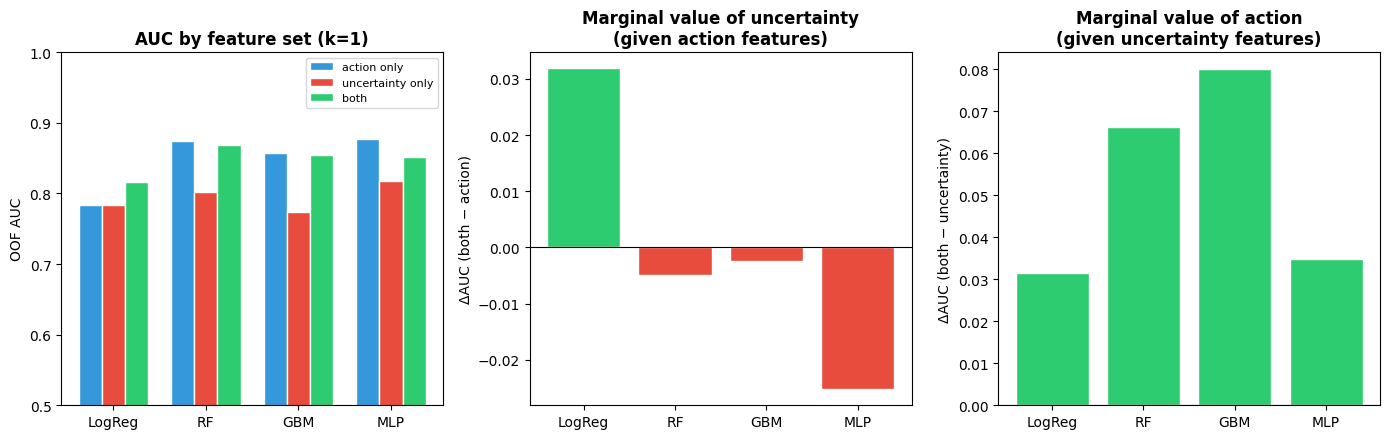

Saved /content/drive/MyDrive/cs159_failure_classifier/ablation_k1_bars.png


In [8]:
models = [s[0] for s in MODEL_SPECS]
x = np.arange(len(models))
width = 0.25

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# ── AUC bar chart ──
ax = axes[0]
for i, fs in enumerate(FEATURE_SETS):
    vals = [results[fs][m]['m']['auc'] for m in models]
    ax.bar(x + (i - 1) * width, vals, width, label=fs.replace('_', ' '),
           color=FEAT_COLORS[fs], edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('OOF AUC')
ax.set_title('AUC by feature set (k=1)', fontweight='bold')
ax.set_ylim(0.5, 1.0)
ax.legend(fontsize=8)
ax.axhline(0.5, color='gray', ls='--', lw=0.8)

# ── ΔAUC (both − action) ──
ax = axes[1]
deltas = [results['both'][m]['m']['auc'] - results['action_only'][m]['m']['auc'] for m in models]
colors = ['#2ecc71' if d > 0 else '#e74c3c' for d in deltas]
ax.bar(models, deltas, color=colors, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('ΔAUC (both − action)')
ax.set_title('Marginal value of uncertainty\n(given action features)', fontweight='bold')

# ── ΔAUC (both − uncertainty) ──
ax = axes[2]
deltas = [results['both'][m]['m']['auc'] - results['uncertainty_only'][m]['m']['auc'] for m in models]
colors = ['#2ecc71' if d > 0 else '#e74c3c' for d in deltas]
ax.bar(models, deltas, color=colors, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('ΔAUC (both − uncertainty)')
ax.set_title('Marginal value of action\n(given uncertainty features)', fontweight='bold')

plt.tight_layout()
out = os.path.join(SAVE_DIR, 'ablation_k1_bars.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {out}')

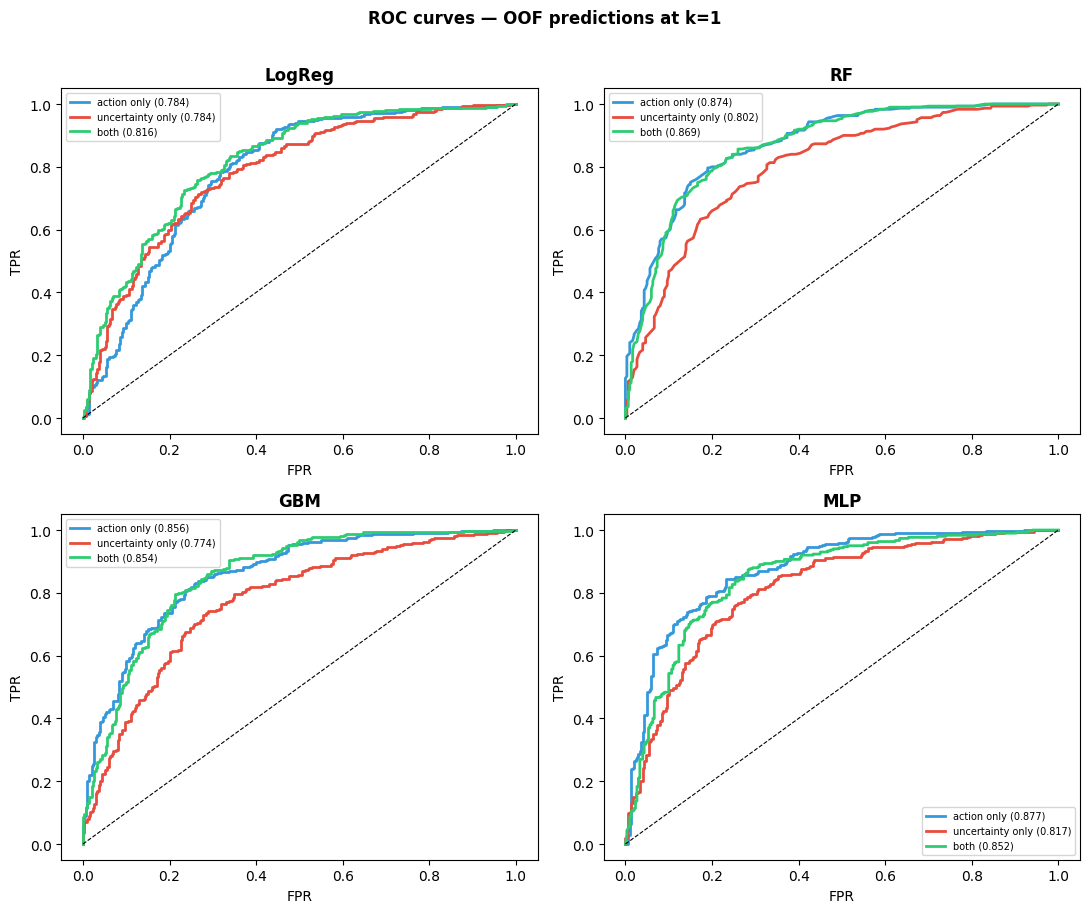

In [9]:
y = datasets['both']['y']

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, model in zip(axes.ravel(), models):
    for fs in FEATURE_SETS:
        prob = results[fs][model]['oof']
        fpr, tpr, _ = roc_curve(y, prob)
        auc = results[fs][model]['m']['auc']
        ax.plot(fpr, tpr, lw=2, color=FEAT_COLORS[fs],
                label=f"{fs.replace('_', ' ')} ({auc:.3f})")
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_title(model, fontweight='bold')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(fontsize=7)

fig.suptitle('ROC curves — OOF predictions at k=1', fontweight='bold', y=1.01)
plt.tight_layout()
out = os.path.join(SAVE_DIR, 'ablation_k1_roc.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()

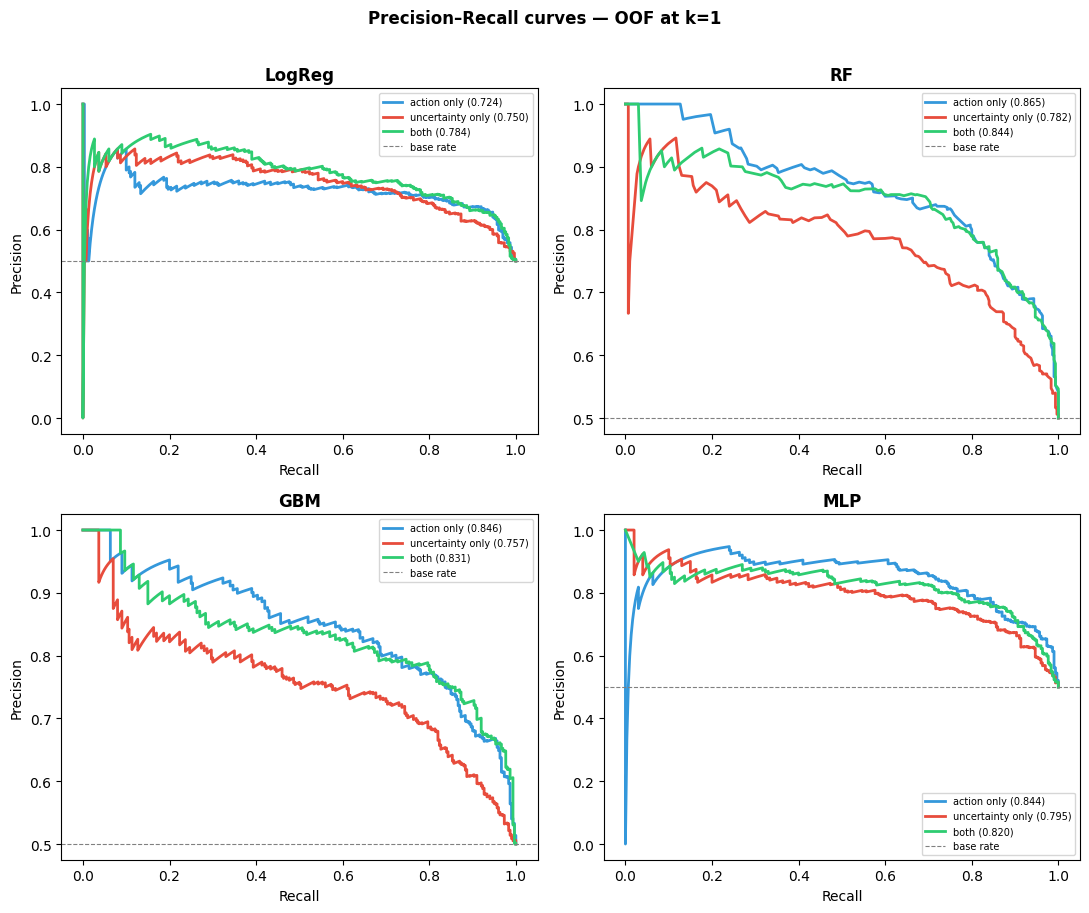

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, model in zip(axes.ravel(), models):
    for fs in FEATURE_SETS:
        prob = results[fs][model]['oof']
        prec, rec, _ = precision_recall_curve(y, prob)
        ap = results[fs][model]['m']['ap']
        ax.plot(rec, prec, lw=2, color=FEAT_COLORS[fs],
                label=f"{fs.replace('_', ' ')} ({ap:.3f})")
    ax.axhline(y.mean(), color='gray', ls='--', lw=0.8, label='base rate')
    ax.set_title(model, fontweight='bold')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend(fontsize=7)

fig.suptitle('Precision–Recall curves — OOF at k=1', fontweight='bold', y=1.01)
plt.tight_layout()
out = os.path.join(SAVE_DIR, 'ablation_k1_pr.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()

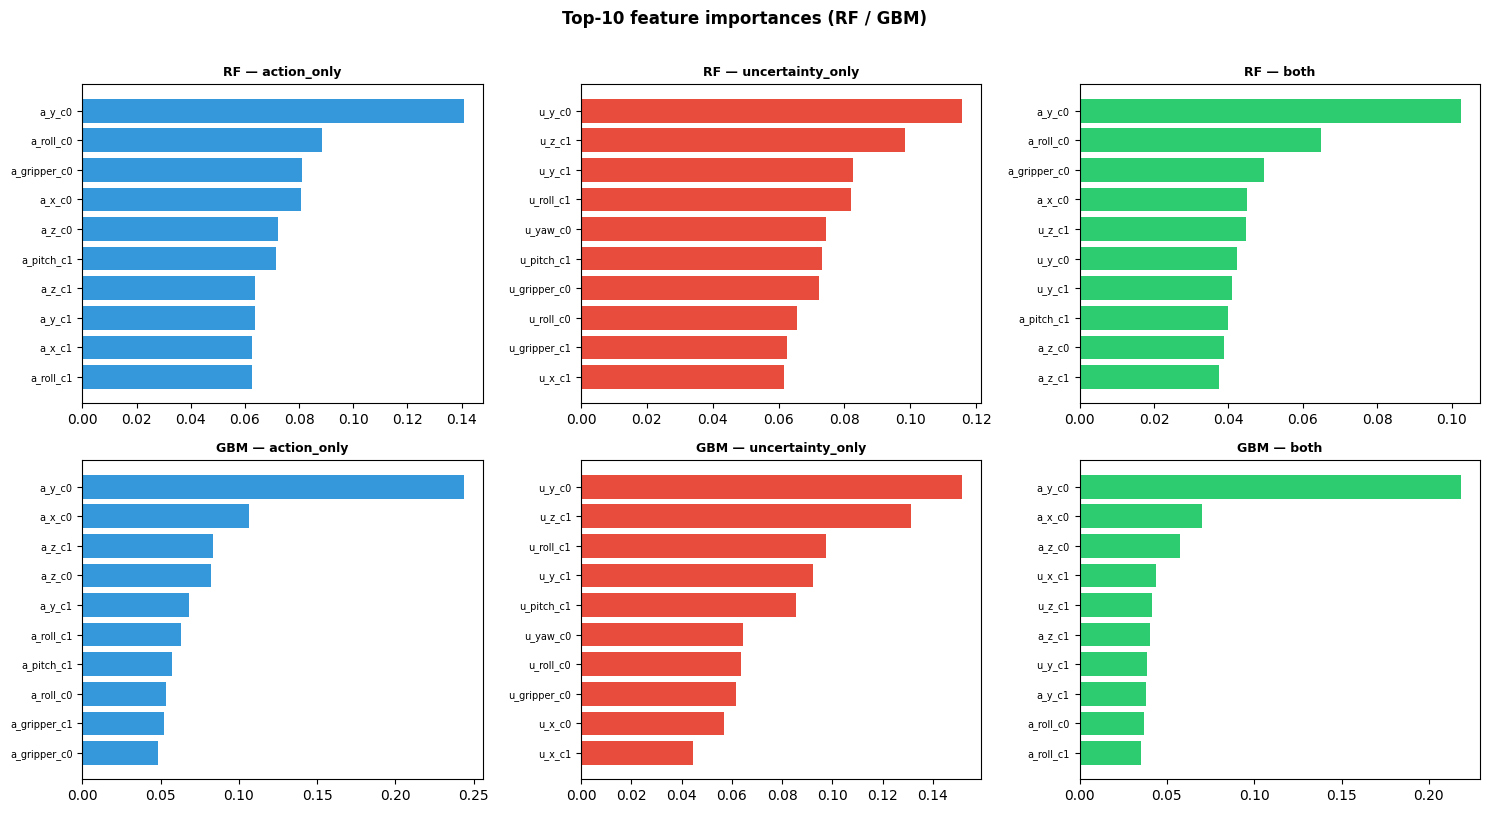

In [11]:
# Feature importances for tree models (RF, GBM)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for row, model in enumerate(['RF', 'GBM']):
    for col, fs in enumerate(FEATURE_SETS):
        ax = axes[row, col]
        imp = results[fs][model]['imp']
        names = datasets[fs]['names']
        if imp is None:
            ax.set_visible(False)
            continue
        order = np.argsort(imp)[::-1][:10]
        ax.barh([names[i] for i in order][::-1], imp[order][::-1],
                color=FEAT_COLORS[fs])
        ax.set_title(f'{model} — {fs}', fontsize=9, fontweight='bold')
        ax.tick_params(axis='y', labelsize=7)

fig.suptitle('Top-10 feature importances (RF / GBM)', fontweight='bold', y=1.01)
plt.tight_layout()
out = os.path.join(SAVE_DIR, 'ablation_k1_importance.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()

## 8. Automatic interpretation

In [12]:
def verdict_line(model):
    auc_a = results['action_only'][model]['m']['auc']
    auc_u = results['uncertainty_only'][model]['m']['auc']
    auc_b = results['both'][model]['m']['auc']
    d_ba = bootstrap_auc_diff(y, results['action_only'][model]['oof'],
                              results['both'][model]['oof'])
    d_bu = bootstrap_auc_diff(y, results['uncertainty_only'][model]['oof'],
                              results['both'][model]['oof'])
    d_ua = bootstrap_auc_diff(y, results['action_only'][model]['oof'],
                              results['uncertainty_only'][model]['oof'])

    lines = [f'\n=== {model} ===']
    lines.append(f'  AUC  action={auc_a:.3f}  uncertainty={auc_u:.3f}  both={auc_b:.3f}')
    lines.append(
        f'  both vs action:      Δ={d_ba["mean"]:+.3f}  '
        f'95% CI [{d_ba["ci_lo"]:+.3f}, {d_ba["ci_hi"]:+.3f}]  p={d_ba["p"]:.3f}'
    )
    lines.append(
        f'  both vs uncertainty: Δ={d_bu["mean"]:+.3f}  '
        f'95% CI [{d_bu["ci_lo"]:+.3f}, {d_bu["ci_hi"]:+.3f}]  p={d_bu["p"]:.3f}'
    )
    lines.append(
        f'  uncertainty vs action: Δ={d_ua["mean"]:+.3f}  '
        f'95% CI [{d_ua["ci_lo"]:+.3f}, {d_ua["ci_hi"]:+.3f}]  p={d_ua["p"]:.3f}'
    )

    # Marginal value of uncertainty beyond action
    if d_ba['ci_lo'] > 0:
        unc_msg = 'Uncertainty ADDS significant info beyond action.'
    elif d_ba['ci_hi'] < 0:
        unc_msg = 'Uncertainty HURTS vs action alone (redundant/noisy).'
    else:
        unc_msg = 'Uncertainty does NOT significantly change AUC vs action alone.'

    # Which single modality is stronger?
    if d_ua['ci_lo'] > 0:
        cmp_msg = 'Uncertainty-only beats action-only.'
    elif d_ua['ci_hi'] < 0:
        cmp_msg = 'Action-only beats uncertainty-only.'
    else:
        cmp_msg = 'Action and uncertainty are statistically tied alone.'

    lines.append(f'  → {unc_msg}')
    lines.append(f'  → {cmp_msg}')
    return '\n'.join(lines)


print('=' * 72)
print('ABLATION VERDICT at k=1')
print('=' * 72)
for model in models:
    print(verdict_line(model))

# Aggregate across models
mean_d_ba = pivot_auc['Δ(both−action)'].mean()
mean_d_ua = pivot_auc['Δ(uncertainty−action)'].mean()
best_single = 'uncertainty' if pivot_auc['uncertainty_only'].mean() > pivot_auc['action_only'].mean() else 'action'
best_both_gain = pivot_auc['Δ(both−action)'].max()
best_both_model = pivot_auc['Δ(both−action)'].idxmax()

print('\n' + '=' * 72)
print('AGGREGATE (across models)')
print('=' * 72)
print(f'  Mean AUC — action: {pivot_auc["action_only"].mean():.3f}  '
      f'uncertainty: {pivot_auc["uncertainty_only"].mean():.3f}  '
      f'both: {pivot_auc["both"].mean():.3f}')
print(f'  Mean Δ(both−action): {mean_d_ba:+.3f}')
print(f'  Mean Δ(uncertainty−action): {mean_d_ua:+.3f}')
print(f'  Stronger single modality on average: {best_single}')
print(f'  Largest marginal gain from combining: {best_both_model} (+{best_both_gain:.3f} AUC)')

if mean_d_ba > 0.01 and (boot_df[(boot_df.comparison == 'both vs action_only')]['ci_lo'] > 0).any():
    headline = (
        'YES — P&P uncertainty adds information beyond the action vector for at least one model.'
    )
elif mean_d_ba < -0.005:
    headline = (
        'NO — combining uncertainty does not help; action features alone are sufficient or better.'
    )
else:
    headline = (
        'INCONCLUSIVE — uncertainty provides little marginal AUC gain beyond action at k=1.'
    )
print(f'\n  HEADLINE: {headline}')
print('=' * 72)

ABLATION VERDICT at k=1

=== LogReg ===
  AUC  action=0.784  uncertainty=0.784  both=0.816
  both vs action:      Δ=+0.032  95% CI [+0.011, +0.054]  p=0.003
  both vs uncertainty: Δ=+0.032  95% CI [+0.008, +0.057]  p=0.009
  uncertainty vs action: Δ=+0.001  95% CI [-0.039, +0.038]  p=0.983
  → Uncertainty ADDS significant info beyond action.
  → Action and uncertainty are statistically tied alone.

=== RF ===
  AUC  action=0.874  uncertainty=0.802  both=0.869
  both vs action:      Δ=-0.005  95% CI [-0.019, +0.010]  p=0.521
  both vs uncertainty: Δ=+0.066  95% CI [+0.042, +0.091]  p=0.000
  uncertainty vs action: Δ=-0.071  95% CI [-0.103, -0.040]  p=0.000
  → Uncertainty does NOT significantly change AUC vs action alone.
  → Action-only beats uncertainty-only.

=== GBM ===
  AUC  action=0.856  uncertainty=0.774  both=0.854
  both vs action:      Δ=-0.002  95% CI [-0.023, +0.017]  p=0.815
  both vs uncertainty: Δ=+0.080  95% CI [+0.052, +0.110]  p=0.000
  uncertainty vs action: Δ=-0.082

## 9. V&V — Rollout length controls

Check whether failure can be predicted from episode length proxies alone (`num_chunks`, `n_steps`), then re-run classifiers on a **chunk-count–matched** cohort (balanced successes/failures within each bin).

In [13]:
length_diag_rows = [
    diagnostic_scalar_auc(ep_chunks, 'num_chunks', 'num_chunks'),
    diagnostic_scalar_auc(ep_chunks, 'n_steps', 'n_steps'),
]
length_diag_df = pd.DataFrame(length_diag_rows)
print('=== Length-proxy leakage diagnostics (LogReg, 5-fold CV) ===')
display(length_diag_df.round(4))

ep_matched = build_matched_cohort(ep_chunks, K)
print(f'\nMatched cohort: n={len(ep_matched)}  '
      f'failures={int(ep_matched.y_fail.sum())}  '
      f'chunk bins={sorted(ep_matched.num_chunks.unique())}')
print(ep_matched.groupby(['num_chunks', 'y_fail']).size().unstack(fill_value=0))

length_rows = []
for cohort_name, ep_df in [('full', ep_chunks), ('matched', ep_matched)]:
    for fs in OOD_FEATURE_SETS:
        X, y, _ = build_Xy(K, fs, ep_df=ep_df)
        for model_name in OOD_MODELS:
            if model_name == 'MLP':
                r = train_mlp_cv(X, y)
            else:
                r = classical_cv(X, y, MODEL_FN[model_name])
            if r is None:
                continue
            length_rows.append(dict(
                cohort=cohort_name, feature_set=fs, model=model_name,
                n=len(y), n_fail=int(y.sum()), auc=r['m']['auc'], f1=r['m']['f1'],
            ))

length_ctrl_df = pd.concat([
    length_diag_df.assign(kind='diagnostic'),
    pd.DataFrame(length_rows).assign(kind='classifier'),
], ignore_index=True)
display(length_ctrl_df.round(4))
length_ctrl_df.to_csv(os.path.join(SAVE_DIR, 'vv_length_controls.csv'), index=False)
print(f'Saved {SAVE_DIR}/vv_length_controls.csv')

=== Length-proxy leakage diagnostics (LogReg, 5-fold CV) ===


,feature,auc,n
0,num_chunks,0.9753,600
1,n_steps,0.9994,600



Matched cohort: n=24  failures=12  chunk bins=[np.int64(6)]
y_fail       0   1
num_chunks        
6           12  12


,feature,auc,n,kind,cohort,feature_set,model,n_fail,f1
0,num_chunks,0.9753,600,diagnostic,NaN,NaN,NaN,NaN,NaN
1,n_steps,0.9994,600,diagnostic,NaN,NaN,NaN,NaN,NaN
2,NaN,0.7843,600,classifier,full,uncertainty_only,LogReg,300.0,0.7454
3,NaN,0.8124,600,classifier,full,uncertainty_only,MLP,300.0,0.7722
4,NaN,0.8157,600,classifier,full,both,LogReg,300.0,0.7715
5,NaN,0.8553,600,classifier,full,both,MLP,300.0,0.8065
6,NaN,0.6389,24,classifier,matched,uncertainty_only,LogReg,12.0,0.6897
7,NaN,0.5694,24,classifier,matched,uncertainty_only,MLP,12.0,0.6667
8,NaN,0.6806,24,classifier,matched,both,LogReg,12.0,0.7059
9,NaN,0.6250,24,classifier,matched,both,MLP,12.0,0.6897


Saved /content/drive/MyDrive/cs159_failure_classifier/vv_length_controls.csv


## 10. V&V — Cross-task OOD generalization (LIBERO-PRO)

Train on `libero_goal_with_yellow_book` (100 eps), evaluate on `libero_spatial_with_milk` (100 eps). Also report the reverse split.

In [14]:
ep_k = ep_chunks[ep_chunks['num_chunks'] >= K + 1].copy()
suites = ep_k['suite']

OOD_SPLITS = [
    (GOAL_SUITE, SPATIAL_SUITE, 'goal_train_spatial_test'),
    (SPATIAL_SUITE, GOAL_SUITE, 'spatial_train_goal_test'),
]

ood_rows = []
ood_results = {}
for train_suite, test_suite, split_name in OOD_SPLITS:
    ood_results[split_name] = {}
    print(f'\n=== {split_name}: train={train_suite}  test={test_suite} ===')
    for fs in OOD_FEATURE_SETS:
        X, y, _ = build_Xy(K, fs, ep_df=ep_k)
        ood_results[split_name][fs] = {}
        for model_name in OOD_MODELS:
            r = train_eval_ood(X, y, suites, train_suite, test_suite, model_name)
            ood_results[split_name][fs][model_name] = r
            if r is None:
                print(f'  {fs:18s} {model_name:6s}: skipped (insufficient class balance)')
                continue
            print(f'  {fs:18s} {model_name:6s}: test AUC={r["m"]["auc"]:.3f}  '
                  f'F1={r["m"]["f1"]:.3f}  (train n={r["n_train"]}, test n={r["n_test"]})')
            ood_rows.append(dict(
                split=split_name, train_suite=train_suite, test_suite=test_suite,
                feature_set=fs, model=model_name,
                n_train=r['n_train'], n_test=r['n_test'],
                test_auc=r['m']['auc'], test_ap=r['m']['ap'], test_f1=r['m']['f1'],
            ))

ood_df = pd.DataFrame(ood_rows)
display(ood_df.round(4))
ood_df.to_csv(os.path.join(SAVE_DIR, 'vv_ood_goal_to_spatial.csv'), index=False)
print(f'\nSaved {SAVE_DIR}/vv_ood_goal_to_spatial.csv')


=== goal_train_spatial_test: train=libero_goal_with_yellow_book  test=libero_spatial_with_milk ===
  uncertainty_only   LogReg: test AUC=0.464  F1=0.195  (train n=100, test n=100)
  uncertainty_only   MLP   : test AUC=0.503  F1=0.167  (train n=100, test n=100)
  both               LogReg: test AUC=0.549  F1=0.160  (train n=100, test n=100)
  both               MLP   : test AUC=0.545  F1=0.091  (train n=100, test n=100)

=== spatial_train_goal_test: train=libero_spatial_with_milk  test=libero_goal_with_yellow_book ===
  uncertainty_only   LogReg: test AUC=0.376  F1=0.150  (train n=100, test n=100)
  uncertainty_only   MLP   : test AUC=0.458  F1=0.111  (train n=100, test n=100)
  both               LogReg: test AUC=0.391  F1=0.000  (train n=100, test n=100)
  both               MLP   : test AUC=0.456  F1=0.000  (train n=100, test n=100)


,split,train_suite,test_suite,feature_set,model,n_train,n_test,test_auc,test_ap,test_f1
0,goal_train_spatial_test,libero_goal_with_yellow_book,libero_spatial_with_milk,uncertainty_only,LogReg,100,100,0.4644,0.2810,0.1951
1,goal_train_spatial_test,libero_goal_with_yellow_book,libero_spatial_with_milk,uncertainty_only,MLP,100,100,0.5031,0.3225,0.1667
2,goal_train_spatial_test,libero_goal_with_yellow_book,libero_spatial_with_milk,both,LogReg,100,100,0.5494,0.2959,0.1600
3,goal_train_spatial_test,libero_goal_with_yellow_book,libero_spatial_with_milk,both,MLP,100,100,0.5450,0.2944,0.0909
4,spatial_train_goal_test,libero_spatial_with_milk,libero_goal_with_yellow_book,uncertainty_only,LogReg,100,100,0.3756,0.0875,0.1500
5,spatial_train_goal_test,libero_spatial_with_milk,libero_goal_with_yellow_book,uncertainty_only,MLP,100,100,0.4578,0.1323,0.1111
6,spatial_train_goal_test,libero_spatial_with_milk,libero_goal_with_yellow_book,both,LogReg,100,100,0.3911,0.0899,0.0000
7,spatial_train_goal_test,libero_spatial_with_milk,libero_goal_with_yellow_book,both,MLP,100,100,0.4556,0.1162,0.0000



Saved /content/drive/MyDrive/cs159_failure_classifier/vv_ood_goal_to_spatial.csv


## 11. V&V summary figures

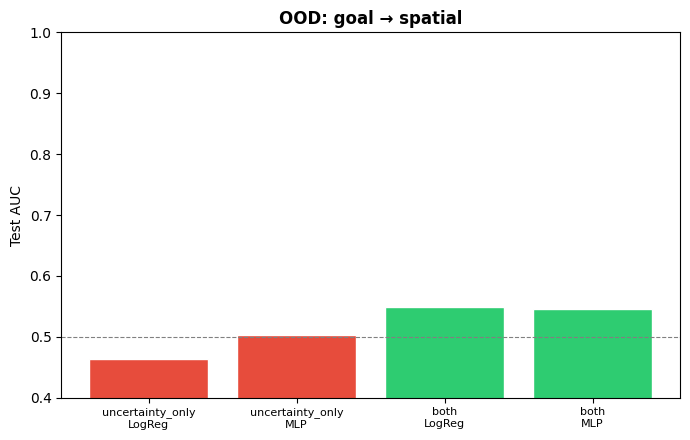

Saved /content/drive/MyDrive/cs159_failure_classifier/vv_summary.png


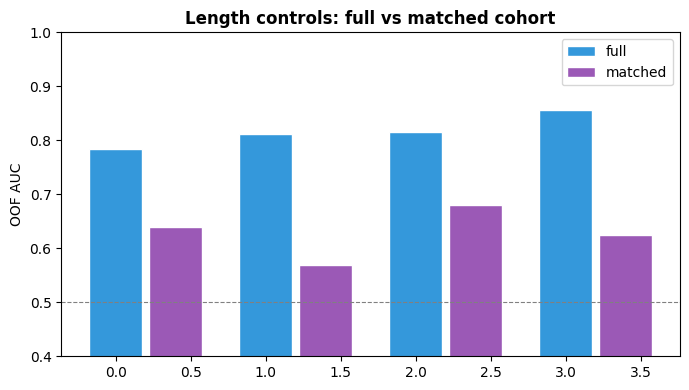

Saved /content/drive/MyDrive/cs159_failure_classifier/vv_length_controls.png

=== V&V outputs ===
  OK    /content/drive/MyDrive/cs159_failure_classifier/vv_length_controls.csv
  OK    /content/drive/MyDrive/cs159_failure_classifier/vv_ood_goal_to_spatial.csv
  OK    /content/drive/MyDrive/cs159_failure_classifier/vv_summary.png
  OK    /content/drive/MyDrive/cs159_failure_classifier/vv_length_controls.png


In [15]:
fig, ax = plt.subplots(figsize=(7, 4.5))

primary = ood_df[ood_df['split'] == 'goal_train_spatial_test'] if len(ood_df) else pd.DataFrame()
if len(primary):
    labels = [f"{r['feature_set']}\n{r['model']}" for _, r in primary.iterrows()]
    vals = primary['test_auc'].values
    colors = ['#e74c3c' if 'uncertainty' in fs else '#2ecc71' for fs in primary['feature_set']]
    ax.bar(range(len(vals)), vals, color=colors, edgecolor='white')
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylim(0.4, 1.0)
    ax.axhline(0.5, color='gray', ls='--', lw=0.8)
    ax.set_ylabel('Test AUC')
    ax.set_title('OOD: goal → spatial', fontweight='bold')
else:
    ax.text(0.5, 0.5, 'No OOD results', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
vv_fig_path = os.path.join(SAVE_DIR, 'vv_summary.png')
plt.savefig(vv_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {vv_fig_path}')

# ── Length controls: full vs matched ──
if len(length_ctrl_df):
    lc = length_ctrl_df[length_ctrl_df['kind'] == 'classifier']
    if len(lc):
        fig2, ax2 = plt.subplots(figsize=(7, 4))
        for cohort, color in [('full', '#3498db'), ('matched', '#9b59b6')]:
            sub = lc[lc['cohort'] == cohort]
            labels = [f"{r['feature_set']}\n{r['model']}" for _, r in sub.iterrows()]
            vals = sub['auc'].values
            offset = 0 if cohort == 'full' else 0.4
            ax2.bar(np.arange(len(vals)) + offset, vals, 0.35, label=cohort, color=color, edgecolor='white')
        ax2.set_ylim(0.4, 1.0)
        ax2.axhline(0.5, color='gray', ls='--', lw=0.8)
        ax2.set_ylabel('OOF AUC')
        ax2.set_title('Length controls: full vs matched cohort', fontweight='bold')
        ax2.legend()
        plt.tight_layout()
        lc_path = os.path.join(SAVE_DIR, 'vv_length_controls.png')
        plt.savefig(lc_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved {lc_path}')

print('\n=== V&V outputs ===')
for fname in ['vv_length_controls.csv', 'vv_ood_goal_to_spatial.csv',
              'vv_summary.png', 'vv_length_controls.png']:
    path = os.path.join(SAVE_DIR, fname)
    print(f'  {"OK" if os.path.exists(path) else "SKIP":4s}  {path}')